In [ ]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("GPU tidak aktif")

True
Tesla T4


##Install Library

In [ ]:
!pip install transformers datasets evaluate accelerate scikit-learn -q

In [ ]:
!pip install -U torch torchvision torchaudio transformers datasets accelerate evaluate scikit-learn

## Import Library

In [ ]:
import pandas as pd
import numpy as np
import re
import torch
import random
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
    set_seed
)

from scipy.special import softmax

##Set Seed

In [ ]:
import random
import numpy as np
import torch
from transformers import set_seed

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed digunakan:", SEED)

Seed digunakan: 42


##Load Data Split


In [ ]:
print("Upload train_indobert.csv, validation_indobert.csv, dan test_indobert.csv")
uploaded = files.upload()

train_df = pd.read_csv("train_indobert.csv")
val_df = pd.read_csv("validation_indobert.csv")
test_df = pd.read_csv("test_indobert.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

display(train_df.head())

Upload train_indobert.csv, validation_indobert.csv, dan test_indobert.csv


Saving test_indobert.csv to test_indobert (5).csv
Saving train_indobert.csv to train_indobert (5).csv
Saving validation_indobert.csv to validation_indobert (5).csv
Train: (972, 7)
Validation: (121, 7)
Test: (122, 7)


,No,cleaning,label,dimensi_MBI,catatan,teks_final,label_id
0,780,mau ngeluh capek kerja tapi dapet duit,tidak_burnout,tidak_burnout,-,mau ngeluh capek kerja tapi dapet duit,0
1,9,sebenernya capek kerja sama dengan orangorang ...,burnout,CY,-,sebenernya capek kerja sama dengan orangorang ...,1
2,859,capek kerja pengen jadi princess aja,burnout,CY,sarkasme-CY,capek kerja pengen jadi princess aja,1
3,83,biar pak suami aja yg kerja matian kita udah c...,burnout,EE,sarkasme-EE,biar pak suami aja yg kerja matian kita udah c...,1
4,481,gaji dikit atasan toxiiicc parahh aduh mending...,burnout,CY,-,gaji dikit atasan toxiiicc parahh aduh mending...,1


##Distribusi Label

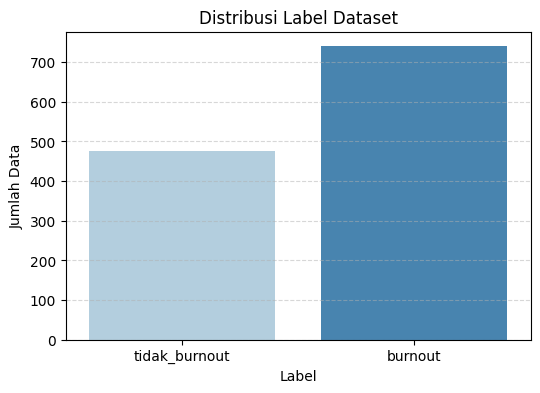

Distribusi label:
label
burnout          740
tidak_burnout    475
Name: count, dtype: int64

Persentase distribusi label:
label
burnout          60.91
tidak_burnout    39.09
Name: proportion, dtype: float64


In [ ]:
df_gabungan = pd.concat([train_df, val_df, test_df], ignore_index=True)

plt.figure(figsize=(6, 4))
sns.countplot(
    data=df_gabungan,
    x="label",
    hue="label",
    palette="Blues",
    legend=False
)

plt.title("Distribusi Label Dataset")
plt.xlabel("Label")
plt.ylabel("Jumlah Data")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

print("Distribusi label:")
print(df_gabungan["label"].value_counts())

print("\nPersentase distribusi label:")
print((df_gabungan["label"].value_counts(normalize=True) * 100).round(2))

##Distribusi Panjang Token atau Teks

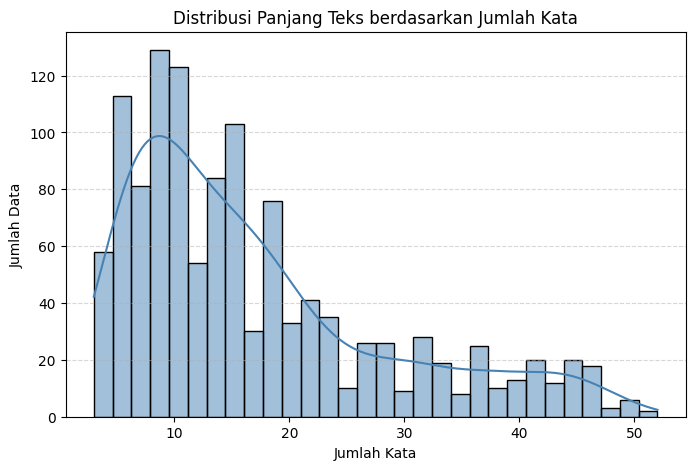

Statistik panjang teks berdasarkan jumlah kata:
count    1215.000000
mean       16.989300
std        11.408358
min         3.000000
25%         8.000000
50%        14.000000
75%        22.000000
max        52.000000
Name: panjang_teks_kata, dtype: float64


In [ ]:
df_gabungan["panjang_teks_kata"] = df_gabungan["teks_final"].apply(
    lambda x: len(str(x).split())
)

plt.figure(figsize=(8, 5))
sns.histplot(
    df_gabungan["panjang_teks_kata"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribusi Panjang Teks berdasarkan Jumlah Kata")
plt.xlabel("Jumlah Kata")
plt.ylabel("Jumlah Data")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

print("Statistik panjang teks berdasarkan jumlah kata:")
print(df_gabungan["panjang_teks_kata"].describe())

## Cek Kolom

In [ ]:
kolom_wajib = ["teks_final", "label_id"]

for data_name, data in {
    "train": train_df,
    "validation": val_df,
    "test": test_df
}.items():
    for kolom in kolom_wajib:
        if kolom not in data.columns:
            raise ValueError(f"Kolom '{kolom}' tidak ditemukan pada data {data_name}")

train_df = train_df[["teks_final", "label_id"]].dropna()
val_df = val_df[["teks_final", "label_id"]].dropna()
test_df = test_df[["teks_final", "label_id"]].dropna()

train_df["label_id"] = train_df["label_id"].astype(int)
val_df["label_id"] = val_df["label_id"].astype(int)
test_df["label_id"] = test_df["label_id"].astype(int)

print("Label train:")
print(train_df["label_id"].value_counts())

print("Label validation:")
print(val_df["label_id"].value_counts())

print("Label test:")
print(test_df["label_id"].value_counts())

Label train:
label_id
1    592
0    380
Name: count, dtype: int64
Label validation:
label_id
1    74
0    47
Name: count, dtype: int64
Label test:
label_id
1    74
0    48
Name: count, dtype: int64


## Load Tokenizer Indobert

In [ ]:
model_name = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(model_name)

id2label = {
    0: "tidak_burnout",
    1: "burnout"
}

label2id = {
    "tidak_burnout": 0,
    "burnout": 1
}

print("Tokenizer berhasil diload:", model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizer berhasil diload: indobenchmark/indobert-base-p1


##Distiribusi Label

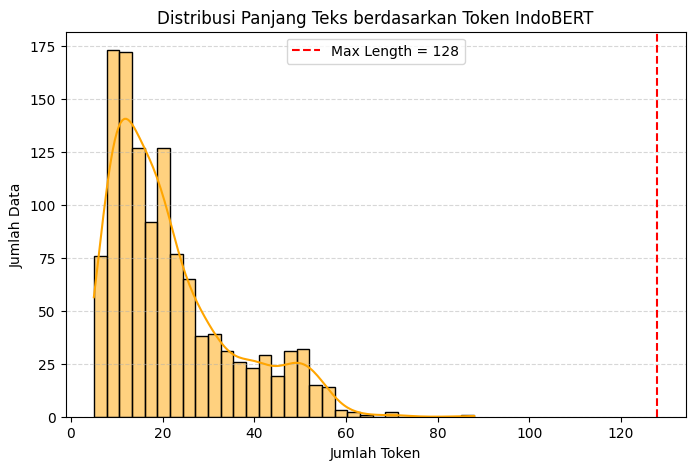

Statistik panjang teks berdasarkan token:
count    1215.000000
mean       21.595062
std        13.312453
min         5.000000
25%        11.000000
50%        18.000000
75%        28.000000
max        88.000000
Name: panjang_teks_token, dtype: float64

Jumlah teks dengan token > 128: 0
Persentase teks dengan token > 128: 0.0 %


In [ ]:
df_gabungan = pd.concat([train_df, val_df, test_df], ignore_index=True)

def hitung_panjang_token(text):
    return len(
        tokenizer(
            str(text),
            add_special_tokens=True,
            truncation=False
        )["input_ids"]
    )

df_gabungan["panjang_teks_token"] = df_gabungan["teks_final"].apply(hitung_panjang_token)

plt.figure(figsize=(8, 5))
sns.histplot(
    df_gabungan["panjang_teks_token"],
    bins=30,
    kde=True,
    color="orange"
)

plt.axvline(
    x=128,
    color="red",
    linestyle="--",
    label="Max Length = 128"
)

plt.title("Distribusi Panjang Teks berdasarkan Token IndoBERT")
plt.xlabel("Jumlah Token")
plt.ylabel("Jumlah Data")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

print("Statistik panjang teks berdasarkan token:")
print(df_gabungan["panjang_teks_token"].describe())

jumlah_lebih_128 = (df_gabungan["panjang_teks_token"] > 128).sum()
persen_lebih_128 = jumlah_lebih_128 / len(df_gabungan) * 100

print("\nJumlah teks dengan token > 128:", jumlah_lebih_128)
print("Persentase teks dengan token > 128:", round(persen_lebih_128, 2), "%")

## Convert Pandas

In [ ]:
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

def tokenize_function(batch):
    return tokenizer(
        batch["teks_final"],
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.rename_column("label_id", "labels")
val_dataset = val_dataset.rename_column("label_id", "labels")
test_dataset = test_dataset.rename_column("label_id", "labels")

train_dataset.set_format("torch")
val_dataset.set_format("torch")
test_dataset.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Map:   0%|          | 0/972 [00:00<?, ? examples/s]

Map:   0%|          | 0/121 [00:00<?, ? examples/s]

Map:   0%|          | 0/122 [00:00<?, ? examples/s]

Dataset({
    features: ['teks_final', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 972
})
Dataset({
    features: ['teks_final', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 121
})
Dataset({
    features: ['teks_final', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 122
})


## Load Model Indobert Untuk Klasifikasi

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

print("Model berhasil diload:", model_name)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model berhasil diload: indobenchmark/indobert-base-p1


## Fungsi Metrik Evaluasi

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

##Setting Training

In [ ]:
training_args = TrainingArguments(
    output_dir="./hasil_finetuning_indobert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1.8e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    report_to="none",
    seed=SEED,
    data_seed=SEED
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


##Trainer

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=3)
    ]
)

print("Trainer siap.")

Trainer siap.


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.662566,0.558867,0.685950,0.708668,0.685950,0.638810
2,0.440743,0.459963,0.809917,0.827905,0.809917,0.812243
3,0.286777,0.532479,0.776860,0.786437,0.776860,0.779053
4,0.143690,0.665447,0.801653,0.801653,0.801653,0.801653
5,0.087233,0.785293,0.768595,0.765828,0.768595,0.765214


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=155, training_loss=0.34801445353415705, metrics={'train_runtime': 145.1717, 'train_samples_per_second': 66.955, 'train_steps_per_second': 2.135, 'total_flos': 139093248305040.0, 'train_loss': 0.34801445353415705, 'epoch': 5.0})

## Evaluasi Data Test

In [ ]:
test_result = trainer.evaluate(test_dataset)

print("Hasil evaluasi test:")
print(test_result)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.087233,0.457908,5,0.795082,0.804066,0.795082,0.796959


Hasil evaluasi test:
{'eval_loss': 0.45790809392929077, 'eval_accuracy': 0.7950819672131147, 'eval_precision': 0.8040661076139423, 'eval_recall': 0.7950819672131147, 'eval_f1': 0.7969585835018054}


##Prediksi Data Test

In [ ]:
predictions = trainer.predict(test_dataset)

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

print("Classification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["tidak_burnout", "burnout"],
        zero_division=0
    )
)

Classification Report:
               precision    recall  f1-score   support

tidak_burnout       0.71      0.81      0.76        48
      burnout       0.87      0.78      0.82        74

     accuracy                           0.80       122
    macro avg       0.79      0.80      0.79       122
 weighted avg       0.80      0.80      0.80       122



## Confusion Matrix

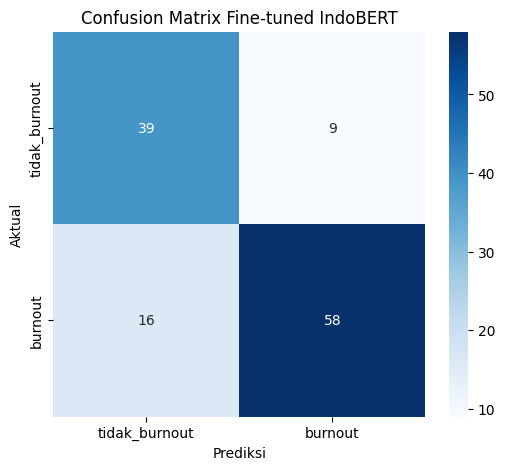

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["tidak_burnout", "burnout"],
    yticklabels=["tidak_burnout", "burnout"]
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Fine-tuned IndoBERT")
plt.show()

##Simpan model fine-tuned

In [ ]:
trainer.save_model("./model_finetuned_indobert_burnout")
tokenizer.save_pretrained("./model_finetuned_indobert_burnout")

print("Model fine-tuned berhasil disimpan.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model fine-tuned berhasil disimpan.


## Download Model

In [ ]:
!zip -r model_finetuned_indobert_burnout.zip model_finetuned_indobert_burnout

files.download("model_finetuned_indobert_burnout.zip")

updating: model_finetuned_indobert_burnout/ (stored 0%)
updating: model_finetuned_indobert_burnout/tokenizer.json (deflated 71%)
updating: model_finetuned_indobert_burnout/tokenizer_config.json (deflated 43%)
updating: model_finetuned_indobert_burnout/model.safetensors


zip error: Interrupted (aborting)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>